# T035 · 基于 GNN 的分子性质预测


**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

* Paula Linh Kramer, 2022, [Volkamer 实验室](https://volkamerlab.org/), [NextAID](https://nextaid.cs.uni-saarland.de/) 项目, 萨尔大学


## 本教程的目标
在本教程中，我们将首先解释图神经网络（GNN）的基本概念，并介绍两种不同的 GNN 架构。我们将神经网络应用于 `QM9` 数据集，该数据集包含小分子数据。利用这个数据集，我们希望预测分子性质。我们将演示如何使用 PyTorch Geometric 逐步训练和评估 GNN。


### _理论_ 部分内容

* GNN 任务
* 消息传递
* 图卷积网络（GCN）
* 图同构网络（GIN）
* 训练 GNN
* GNN 的应用


### _实践_ 部分内容

* 数据集
* 定义 GCN 和 GIN
* 训练 GNN
* 评估模型


### 参考文献

* 论文：
    * Atz, Kenneth, Francesca Grisoni, and Gisbert Schneider. *Geometric Deep Learning on Molecular Representations*, [Nature Machine Intelligence 3.12 (2021): 1023-1032](https://arxiv.org/pdf/2107.12375.pdf)
    * Xu, Keyulu, Weihua Hu, Jure Leskovec, and Stefanie Jegelka. *How Powerful are Graph Neural Networks?*, [International Conference on Learning Representations (ICLR 2019)](https://arxiv.org/abs/1810.00826v3)
    * Welling, Max, and Thomas N. Kipf. *Semi-supervised classification with graph convolutional networks*, [International Conference on Learning Representations (ICLR 2017)](https://arxiv.org/pdf/1609.02907.pdf)
    * Gilmer, Justin, Samuel S. Schoenholz, Patrick F. Riley, Oriol Vinyals, and George E. Dahl. *Neural Message Passing for Quantum Chemistry*, [International conference on machine learning. PMLR, 2017](https://arxiv.org/pdf/1704.01212.pdf)

* 博客文章：
    * Maxime Labonne, *Graph Convolutional Networks: Introduction to GNNs*, [Maxime Labonne](https://mlabonne.github.io/blog/intrognn/)
    * Maxime Labonne, *GIN: How to Design the Most Powerful Graph Neural Network*, [Maxime Labonne](https://mlabonne.github.io/blog/gin/)
    * Michael Bronstein, *Expressive power of graph neural networks and the Weisfeiler-Lehman test*, [towardsdatascience](https://towardsdatascience.com/expressive-power-of-graph-neural-networks-and-the-weisefeiler-lehman-test-b883db3c7c49)
    * Benjamin Sanchez-Lengeling, Emily Reif, *A Gentle Introduction to Graph Neural Networks*, [Distill](https://distill.pub/2021/gnn-intro/)

* 教程：
    * Pytorch Documentation, *Saving and Loading Models*, [Documentation](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html)
    * *Pytorch Geometric Documentation*, [Colab Notebooks and Video Tutorials](https://pytorch-geometric.readthedocs.io/en/latest/notes/colabs.html)
    * *Pytorch Geometric Documentation*, [Introduction by Example](https://pytorch-geometric.readthedocs.io/en/latest/notes/introduction.html#learning-methods-on-graphs)


In [ ]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 35
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论

### 图神经网络

有几种表示分子的方法，在 **教程 T033** 中已经解释和讨论过。当我们处理分子时，将深度学习应用于某些任务的一种直观方法是利用分子的图结构。图神经网络可以直接处理给定的图。分子很容易表示为图，如图 1 所示。给定一个图 $G=(V, E)$，$V$ 表示顶点或节点。在分子图中，节点 $v_i \in \mathbb{R}^{d_v}$ 代表一个原子。节点可以有 $d_v$ 个不同的特征，例如原子序号和手性。边通常对应于原子之间的共价键。每条边 $e_{ij} \in \mathbb{R}^{d_e}$ 由 $d_e$ 个特征描述，通常表示键类型。图神经网络是由可学习和可微分的函数组成的网络，对于图的排列具有不变性。图神经网络由所谓的消息传递层组成，下面将更详细地解释这些层，随后给出两种不同 GNN 架构的更具体说明。

<p align="center">
<img src="images/simple-graph.png" alt="simple_graph" width="600"/>
</p>
<p align="center">
    <em> 图 1: 分子图概览。图片来自 [<a href="https://arxiv.org/pdf/2107.12375.pdf" target="_top">1</a>]
</em>
</p>


#### GNN 任务

我们可以使用 GNN 执行不同的任务：

- 图级任务：一个应用是预测整个图的特定属性。这可以是分类任务（如毒性预测）或回归任务。在本教程中，我们将实现一个回归任务来预测分子性质。另一个图级任务是预测全新的图/分子。这在药物发现领域尤其重要，因为寻找新的候选药物是核心目标。
- 节点级任务：我们可以预测图中特定节点的属性，例如每个原子的原子电荷。我们还可以预测要添加到图中的新节点。这在分子生成中经常用到，我们需要逐个添加多个原子以形成新分子。
- 边级任务：我们可以预测边的属性，例如原子间的分子内力，或图中的新边。在分子生成中，我们希望预测原子之间的潜在键。边预测也可以用于推断生物网络（如基因调控网络）中的连接/相互作用。


#### 消息传递

与标准神经网络中的 MLP 层不同，GNN 具有消息传递层，在其中我们收集关于邻居节点的信息。对于每个节点 $v$，我们查看直接邻居 $N(v)$ 并收集信息。然后所有信息被聚合，例如使用求和。然后我们用聚合的消息更新节点 $v$。如果我们执行这个聚合和组合，每个节点包含直接邻居的信息（1 跳）。如果我们重复 $n$ 次，我们就聚合了第 $n$ 近的邻居的信息（$n$ 跳）。

$$a_v^{(k)} = \text{aggregate}^{(k)} (\{ h_u^{(k-1)}: u \in N(v) \})$$

$$h_v^{(k)} = \text{combine}^{(k)} (h_v^{(k-1)}, a_v^{(k)})$$

其中 $h_v^{(k)}$ 是节点 $v$ 在第 $k$ 层的嵌入，$N(v)$ 是节点 $v$ 的邻居。

<p align="center">
<img src="images/gnn_overview.png" alt="simple_graph" width="600"/>
</p>
<p align="center">
    <em> 图 2: 消息传递概览。图片来自 [<a href="https://medium.com/stanford-cs224w/self-supervised-learning-for-graphs-963e03b9f809" target="_top">2</a>]
</em>
</p>

GNN 的一个重要特性是置换不变性。这意味着改变图中节点的顺序不应影响结果。例如，使用邻接矩阵时，改变节点的顺序意味着交换行和/或列。然而，这不会改变图的任何属性，但输入会不同。在 GNN 中，我们希望克服这个问题。因此，我们需要一个置换不变的聚合函数和组合函数，例如使用均值、最大值或求和。
使用置换不变的聚合函数可以确保图级输出也对置换具有不变性。
在本教程中，我们将解释图级回归任务，并将在下面介绍两种不同的 GNN 架构。


#### GCN

最简单的 GNN 之一是图卷积网络（GCN）。对于 GCN，我们对节点 $v$ 的所有邻居（包括节点 $v$ 自身）求和并聚合所有信息。我们将其除以度数，以保持不同节点的数值范围可比。第 $k$ 层的节点级聚合函数为：

$$h_v^{(k)} = \Theta^{\top} \sum_{u \in N(v) \cup \{v\}} \frac{1}{\sqrt{d_v d_u}} \cdot h_u^{(k-1)}$$

其中 $d_j$ 和 $d_i$ 分别表示节点 $j$ 和 $i$ 的度数，$\Theta$ 表示可训练的权重。

GCN 的一个缺点是它们使用基于均值的聚合函数，而这个函数不是单射的。这意味着不同的图可能导致相同的图嵌入，网络无法再区分这两个图。一个例子如图 3 所示。假设节点和边的属性相同，GCN 可能为这两个图创建相同的隐藏嵌入。

<p align="center">
<img src="images/graph.jpeg" alt="simple_graph" width="500"/>
</p>
<p align="center">
    <em> 图 3: 使用 GCN 无法区分的两个图
</em>
</p>


#### GIN

另一种类型的 GNN 是图同构网络（GIN），它被提出来克服上面解释的 GCN 的缺点。其聚合函数定义如下：

$$h_v^{(k)} = h_\Theta((1+ \epsilon) \cdot h_v^{(k-1)} + \sum_{u \in N(v)} h_u^{(k-1)} )$$

这里的聚合函数是求和。参数 $\epsilon$ 决定节点 $v$ 相对于其邻居的重要性。$h_\Theta$ 代表所有节点 $v$ 的神经网络，例如一个 MLP。求和聚合函数比均值聚合（用于上面的 GCN）更强大，因为我们可以区分更多相似的图，例如图 3 中的两个图。

GIN 是一个简单但仍然相当强大的网络示例，因为它们非常擅长区分非同构图。如果两个图除了节点排列之外完全相同，则它们称为同构。虽然对于较小的图这可能很容易看出，但对于较大的图来说这是一个复杂的问题。在使用 GNN 时，我们希望如果输入图是同构的，模型能给出相同的输出。另一方面，我们也希望模型能够区分非同构图并输出（可能）不同的结果。GIN 在区分非同构图方面比其他简单的 GNN（如 GCN 和 GraphSage）要好得多。例如，上图中的两个图使用 GIN 会有不同的嵌入，因为我们使用的是基于求和的聚合，没有任何缩放或平均。已经证明 GIN 与 Weisfeiler-Lehman 测试一样强大，这是一种常见（但不完美的）图同构测试。如果你对 WL 测试或 GIN 的更多细节感兴趣，请查看关于 [GIN](https://arxiv.org/abs/1810.00826v3) 的原始论文或这篇关于 WL 测试的[博客文章](https://towardsdatascience.com/expressive-power-of-graph-neural-networks-and-the-weisefeiler-lehman-test-b883db3c7c49)。GIN 无法区分所有非同构图，一个例子在图 4 中。两个图中的每个节点都有相同数量的邻居，因此 $h_v$ 在两个图中的所有节点 $v$ 上都是相同的。

<p align="center">
<img src="images/gin_graphs.jpeg" alt="simple_graph" width="500"/>
</p>
<p align="center">
    <em> 图 4: 使用 GIN 无法区分的两个图
</em>
</p>


#### 训练 GNN

与训练标准神经网络类似，需要决定不同的设计选择和超参数。我们将简要介绍一些神经网络中常用的概念，这些概念也可以用于 GNN。损失函数和激活函数已在 **教程 T022** 中讨论过。我们这里也使用了均方误差损失和 ReLU 激活函数。

##### 批处理

在训练 GNN 时，通常进行批处理以提高性能。批大小表示在更新模型参数之前，有多少训练数据样本被送入神经网络。选择合适的批大小是在计算成本和泛化能力之间的权衡。对于较大的批次，模型更新的次数较少，训练速度更快。使用较小批次的模型可以更好地泛化，这意味着可以降低测试误差。由于这不是唯一的超参数，选择批大小也与学习率、训练 epoch 数量等相关。

在 GNN 中实现批处理的一种方式是将批次中所有图的邻接矩阵对角堆叠，并将节点特征矩阵拼接起来。然而，图（尤其是分子图）可能具有相当稀疏的邻接矩阵。在这种情况下，使用边的稀疏表示更高效。例如，PyTorch Geometric 使用[边列表](https://pytorch-geometric.readthedocs.io/en/latest/notes/batching.html)，其中只保存现有边的索引。在批处理过程中，这些列表被拼接起来。

<p align="center">
<img src="images/batching-ex.png" alt="simple_graph" width="600"/>
</p>
<p align="center">
    <em> 图 5: GNN 中的批处理，图片来自 [<a href="https://blog.dataiku.com/graph-neural-networks-part-three" target="_top">3</a>]
</em>
</p>

#### 池化

池化层帮助神经网络降低维度。这使模型对变化更加稳健。在图神经网络中，全局池化层可以从不同的节点嵌入产生图嵌入。有几种不同的池化方式，最常见的包括均值、最大值和求和，它们都是置换不变的。因此，池化层也是置换不变的。
对于我们的 GCN，我们使用全局均值池化层；对于我们的 GIN，我们使用全局求和池化层，正如上面参考文献中原始论文所提出的那样。池化层对于将层的大小减小到固定的图表示大小也非常有用，因此全局池化层也被称为读出层。

#### Dropout（正则化）

深度学习任务中的一个常见问题是过拟合。这通常意味着用于训练神经网络的数据集太小。将过拟合的网络应用于不同的数据集会导致预测误差很高，因为模型过于贴合训练数据，泛化能力不足。为减少过拟合，一种方法是使用 dropout 层，这可以导致更好的模型泛化。在训练期间，节点被随机丢弃。丢弃节点的概率是另一个需要固定的超参数。在每次迭代中，神经网络中的节点（以及节点数量）因此可能不同。这意味着我们引入了更多噪声，从而迫使神经网络更好地泛化。


### GNN 的应用

GNN 可以应用于涉及图的各种任务，这些可以基于小分子（如本教程），也可以基于蛋白质（参见 **教程 T038**）、基因调控网络等等。一些应用包括：

*   分子的性质预测，如毒性和溶解度（参见：Wieder, Oliver, et al. *A compact review of molecular property prediction with graph neural networks* [Drug Discovery Today: Technologies 37 (2020): 1-12.](https://www.sciencedirect.com/science/article/pii/S1740674920300305) 和 *MoleculeNet: a benchmark for molecular machine learning* by Zhenqin Wu et al., [Chemical science 9.2 (2018): 513-530.](https://pubs.rsc.org/en/content/articlehtml/2018/sc/c7sc02664a)）
*   生成新分子，这在药物发现领域尤其重要（更多详情请阅读 Tong, Xiaochu, et al. 的综述 *Generative models for De Novo drug design* [Journal of Medicinal Chemistry 64.19 (2021): 14011-14027](https://pubs.acs.org/doi/full/10.1021/acs.jmedchem.1c00927)）
*   推断生物网络中的新相互作用/关联，如基因调控网络或蛋白质-蛋白质相互作用网络

要了解更多关于 GNN 及其应用的详细信息，可以阅读 Zhang, Xiao-Meng, et al. 的文章 *Graph Neural Networks and Their Current Applications in Bioinformatics* [Frontiers in Genetics 12 (2021)](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8360394/)。


## 实践

在实践部分，我们使用了 PyTorch 和 PyTorch Geometric，它们帮助我们高效地处理图数据。例如，PyTorch Geometric 使用稀疏矩阵表示并实现了高效的图批处理。不过，Python 也有不同的图库，例如 [Deep Graph Library](https://www.dgl.ai/)，本教程不涉及。


In [1]:
import math
import numpy
import pandas as pd
import matplotlib.pylab as plt
from matplotlib.ticker import MaxNLocator
from pathlib import Path

import torch
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU

In [2]:
from torch_geometric.datasets import QM9
from torch_geometric.nn import GCNConv, GINConv
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, global_add_pool

In [3]:
# 指定本地数据路径
HERE = Path(_dh[-1])
DATA = HERE / "data"

### 数据集

本教程使用 [QM9](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.QM9) 数据集，可以使用 `torch_geometric` 导入。该数据集是名为 [MoleculeNet](https://pubs.rsc.org/en/content/articlehtml/2018/sc/c7sc02664a) 的基准测试集合的一部分。它包含约 130,000 个小分子，最多 9 个重原子，以及各种分子性质。我们将选择一个性质进行预测。


In [4]:
# 加载数据集
qm9 = QM9(root=DATA)
qm9[0]

Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], idx=[1], name='gdb_1', z=[5])

如果你是第一次运行本教程，数据集将在此处下载。下面显示了数据集中的第一个分子作为示例。数据集包含以下信息：
- `x`：包含不同的节点特征，如原子序号、手性、杂化方式、是否芳香、是否成环。
- `edge_index`：邻接矩阵，表示原子之间的共价键。
- `edge_attributes`：包含边的特征（键类型、是否共轭、立体构型）。
- `pos`：3D 原子坐标，本教程中不使用。
- `z`：原子序号。
- `y`：目标值，该数据集包含 19 种不同的性质描述每个分子，如偶极矩、不同分子能量、焓和转动常数。

在本教程中，为简单起见，我们只使用 `x`、`edge_index` 和 `y`。虽然数据集有许多回归目标，但我们只关注其中一个任务：预测偶极矩 $\mu$。本教程中，我们只对 QM9 的一个子集进行采样。这样可以保持较短的运行时间，同时仍然足够展示初步结果。数据集按 $80:10:10$ 的比例分为训练集、验证集和测试集。此外，我们对训练数据进行归一化（$\mu=0, \sigma=1$），并对测试集和验证集应用相同的均值和标准差。


In [5]:
# 获取一个回归目标
y_target = pd.DataFrame(qm9.data.y.numpy())
qm9.data.y = torch.Tensor(y_target[0])

qm9 = qm9.shuffle()

# 数据拆分
data_size = 30000
train_index = int(data_size * 0.8)
test_index = train_index + int(data_size * 0.1)
val_index = test_index + int(data_size * 0.1)


# 归一化数据
data_mean = qm9.data.y[0:train_index].mean()
data_std = qm9.data.y[0:train_index].std()

qm9.data.y = (qm9.data.y - data_mean) / data_std

# datasets into DataLoader
train_loader = DataLoader(qm9[0:train_index], batch_size=64, shuffle=True)
test_loader = DataLoader(qm9[train_index:test_index], batch_size=64, shuffle=True)
val_loader = DataLoader(qm9[test_index:val_index], batch_size=64, shuffle=True)

/var/folders/gh/w26fk3_d4rg66fs_7fz84c3c0000gn/T/ipykernel_6145/3547865351.py:2: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  y_target = pd.DataFrame(qm9.data.y.numpy())
/var/folders/gh/w26fk3_d4rg66fs_7fz84c3c0000gn/T/ipykernel_6145/3547865351.py:3: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppres

### 定义 GCN 和 GIN

以下两个 Python 类是本教程中将要考虑的两种 GNN。两者都有 3 个卷积层、1 个全局池化层、线性层、层间的 ReLU 激活函数以及一个 dropout 层。


In [6]:
class GCN(torch.nn.Module):
    """具有 3 个卷积层和 1 个线性层的图卷积网络类"""

    def __init__(self, dim_h):
        """GCN 的初始化方法

        Args:
            dim_h (int): 隐藏层的维度
        """
        super().__init__()
        self.conv1 = GCNConv(qm9.num_features, dim_h)
        self.conv2 = GCNConv(dim_h, dim_h)
        self.conv3 = GCNConv(dim_h, dim_h)
        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, data):
        e = data.edge_index
        x = data.x

        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        x = x.relu()
        x = self.conv3(x, e)
        x = global_mean_pool(x, data.batch)

        x = Fun.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

In [7]:
class GIN(torch.nn.Module):
    """具有 3 个 GINConv 层和 2 个线性层的图同构网络类"""

    def __init__(self, dim_h):
        """初始化 GIN 类

        Args:
            dim_h (int): 隐藏层的维度
        """
        super(GIN, self).__init__()
        self.conv1 = GINConv(
            Sequential(Linear(11, dim_h), BatchNorm1d(dim_h), ReLU(), Linear(dim_h, dim_h), ReLU())
        )
        self.conv2 = GINConv(
            Sequential(
                Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(), Linear(dim_h, dim_h), ReLU()
            )
        )
        self.conv3 = GINConv(
            Sequential(
                Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(), Linear(dim_h, dim_h), ReLU()
            )
        )
        self.lin1 = Linear(dim_h, dim_h)
        self.lin2 = Linear(dim_h, 1)

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        batch = data.batch

        # Node embeddings
        h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = self.conv3(h, edge_index)

        # Graph-level readout
        h = global_add_pool(h, batch)

        h = self.lin1(h)
        h = h.relu()
        h = Fun.dropout(h, p=0.5, training=self.training)
        h = self.lin2(h)

        return h

### 训练 GNN

在训练 GNN（或任何神经网络）时，我们有训练集、验证集和测试集。训练集用于训练，验证集用于在每个 epoch 不仅在训练集上测试损失，也在另一个数据集上测试（*监控泛化性能*）。测试集用于使用整个训练过程中未使用过的数据集计算完全训练好的模型的误差。


In [8]:
def training(loader, model, loss, optimizer):
    """训练一个 epoch

    Args:
        loader (DataLoader): loader (DataLoader): 分为批次的训练数据
        model (nn.Module): 要训练的 GNN 模型
        loss (nn.functional): 训练期间使用的损失函数
        optimizer (torch.optim): 训练期间的优化器

    Returns:
        浮点数：训练损失
    """
    model.train()

    current_loss = 0
    for d in loader:
        optimizer.zero_grad()
        d.x = d.x.float()

        out = model(d)

        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        current_loss += l / len(loader)
        l.backward()
        optimizer.step()
    return current_loss, model

In [9]:
def validation(loader, model, loss):
    """验证

    Args:
        loader (DataLoader): 分批次的验证集
        model (nn.Module): 当前训练好的模型
        loss (nn.functional): 损失函数

    Returns:
        浮点数：验证损失
    """
    model.eval()
    val_loss = 0
    for d in loader:
        out = model(d)
        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        val_loss += l / len(loader)
    return val_loss

In [10]:
@torch.no_grad()
def testing(loader, model):
    """Testing

    Args:
        loader (DataLoader): test dataset
        model (nn.Module): trained model

    Returns:
        float: test loss
    """
    loss = torch.nn.MSELoss()
    test_loss = 0
    test_target = numpy.empty((0))
    test_y_target = numpy.empty((0))
    for d in loader:
        out = model(d)
        # NOTE
        # out = out.view(d.y.size())
        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        test_loss += l / len(loader)

        # save prediction vs ground truth values for plotting
        test_target = numpy.concatenate((test_target, out.detach().numpy()[:, 0]))
        test_y_target = numpy.concatenate((test_y_target, d.y.detach().numpy()))

    return test_loss, test_target, test_y_target

In [11]:
def train_epochs(epochs, model, train_loader, val_loader, path):
    """训练所有 epoch

    Args:
        epochs (int): 训练的 epoch 数量
        model (nn.Module): 当前模型
        train_loader (DataLoader): 分批次的训练数据
        val_loader (DataLoader): 分批次的验证数据
        path (string): 保存最佳模型的路径

    Returns:
        array: returning train and validation losses over all epochs, prediction and ground truth values for training data in the last epoch
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    loss = torch.nn.MSELoss()

    train_target = numpy.empty((0))
    train_y_target = numpy.empty((0))
    train_loss = numpy.empty(epochs)
    val_loss = numpy.empty(epochs)
    best_loss = math.inf

    for epoch in range(epochs):
        epoch_loss, model = training(train_loader, model, loss, optimizer)
        v_loss = validation(val_loader, model, loss)
        if v_loss < best_loss:
            torch.save(model.state_dict(), path)
        for d in train_loader:
            out = model(d)
            if epoch == epochs - 1:
                # record truly vs predicted values for training data from last epoch
                train_target = numpy.concatenate((train_target, out.detach().numpy()[:, 0]))
                train_y_target = numpy.concatenate((train_y_target, d.y.detach().numpy()))

        train_loss[epoch] = epoch_loss.detach().numpy()
        val_loss[epoch] = v_loss.detach().numpy()

        # print current train and val loss
        if epoch % 2 == 0:
            print(
                "Epoch: "
                + str(epoch)
                + ", Train loss: "
                + str(epoch_loss.item())
                + ", Val loss: "
                + str(v_loss.item())
            )
    return train_loss, val_loss, train_target, train_y_target

我们已经用 100 个 epoch 训练了两种模型，并将最佳模型保存为 `GCN_best-model-parameters.pt` 和 `GIN_best-model-parameters.pt`。由于这需要一些时间，为了演示目的，本教程将 epoch 数减少到 10。下面的结果和图表基于用 100 个 epoch 训练的模型。如果你想使用本教程训练自己的模型，可以更改 epoch 数和模型中的任何其他参数（如学习率、批大小等）。


In [12]:
# 训练 GCN 10 个 epoch
epochs = 10

model = GCN(dim_h=128)

# 如果你想保留之前训练的模型，请更改路径
gcn_train_loss, gcn_val_loss, gcn_train_target, gcn_train_y_target = train_epochs(
    epochs, model, train_loader, test_loader, "GCN_model.pt"
)

Epoch: 0, Train loss: 0.950118362903595, Val loss: 0.8406221866607666
Epoch: 2, Train loss: 0.8693353533744812, Val loss: 0.7571350336074829
Epoch: 4, Train loss: 0.8246764540672302, Val loss: 0.7456464171409607
Epoch: 6, Train loss: 0.7871537208557129, Val loss: 0.7535340785980225
Epoch: 8, Train loss: 0.7626587152481079, Val loss: 0.692962110042572


In [13]:
# 训练 GIN 10 个 epoch
model = GIN(dim_h=64)

# 如果你想保留之前训练的模型，请更改路径
gin_train_loss, gin_val_loss, gin_train_target, gin_train_y_target = train_epochs(
    epochs, model, train_loader, test_loader, "GIN_model.pt"
)

Epoch: 0, Train loss: 0.7335681915283203, Val loss: 0.5826902985572815
Epoch: 2, Train loss: 0.5352157354354858, Val loss: 0.4648858904838562
Epoch: 4, Train loss: 0.49017754197120667, Val loss: 0.4378294348716736
Epoch: 6, Train loss: 0.46423086524009705, Val loss: 0.46342021226882935
Epoch: 8, Train loss: 0.4483247697353363, Val loss: 0.3967725932598114


### 评估模型

为了评估，我们使用验证数据集来找到最佳模型，并使用测试集来测试模型在未见数据上的表现。
首先，我们绘制了训练集和验证集的损失。正如预期，GIN 模型的训练损失和验证损失更低。


In [14]:
def plot_loss(gcn_train_loss, gcn_val_loss, gin_train_loss, gin_val_loss):
    """绘制每个 epoch 的损失

    Args:
        epochs (int): epoch 数量
        train_loss (array): 每个 epoch 的训练损失
        val_loss (array): 每个 epoch 的验证损失
    """
    plt.plot(gcn_train_loss, label="Train loss (GCN)")
    plt.plot(gcn_val_loss, label="Val loss (GCN)")
    plt.plot(gin_train_loss, label="Train loss (GIN)")
    plt.plot(gin_val_loss, label="Val loss (GIN)")
    plt.legend()
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.title("Model Loss")
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()

In [15]:
def plot_targets(pred, ground_truth):
    """在散点图中绘制真实值与预测值

    Args:
        pred (array): 预测值
        ground_truth (array): 真实值
    """
    f, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(pred, ground_truth, s=0.5)
    plt.xlim(-2, 7)
    plt.ylim(-2, 7)
    ax.axline((1, 1), slope=1)
    plt.xlabel("Predicted Value")
    plt.ylabel("Ground truth")
    plt.title("Ground truth vs prediction")
    plt.show()

查看每个 epoch 的损失，我们可以看到 GIN 模型整体上表现更好。我们还可以看到训练损失通常低于验证损失。这是正常的，因为训练损失描述的是模型在用于改进模型的训练集上的误差。验证损失是在一个独立的数据集上计算的，该数据集不用于更新模型权重。因此，误差通常更高。这也是验证损失有时波动更大的原因。只要两个损失都呈现下降趋势，就没有问题。重要的是要有低的训练损失和低的验证损失。


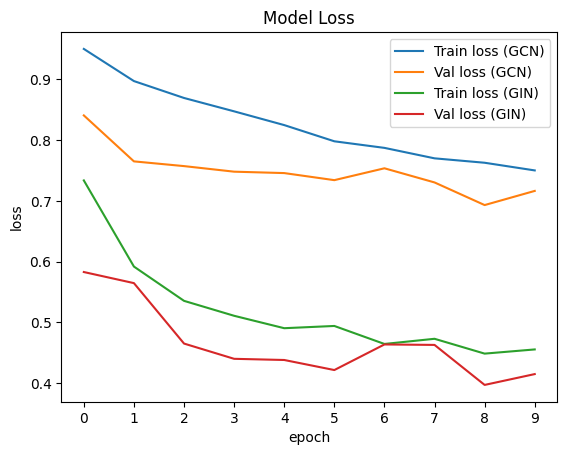

In [16]:
# Plot overall losses of GIN and GCN

plot_loss(gcn_train_loss, gcn_val_loss, gin_train_loss, gin_val_loss)

然后，我们还绘制了 GIN 模型的目标值预测与真实值的对比图，因为这个模型表现更好。


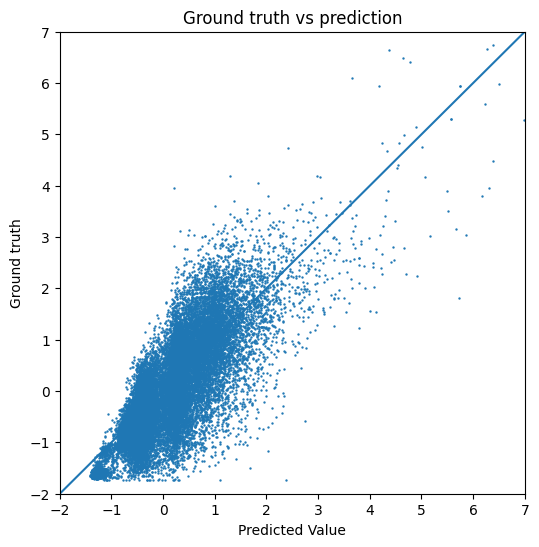

In [17]:
# Plot target and prediction for training data

plot_targets(gin_train_target, gin_train_y_target)

下面，我们计算了 GCN 和 GIN 的测试损失。我们还绘制了两种模型的预测偶极矩与真实值的对比图。如果我们对预测偶极矩的实际数值范围感兴趣，应当重新减去预处理时应用的归一化值。由于我们只是在评估中可视化数据，这没有区别。从下图中可以看出，GIN 模型比 GCN 表现好得多，因为测试误差更低。


Test Loss for GCN: 0.597449004650116


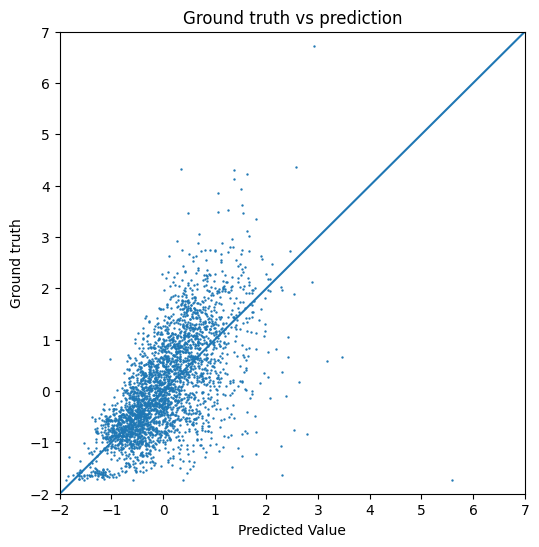

In [18]:
# 计算最佳 GCN 模型的测试损失（根据验证损失）

# 加载模型
model = GCN(dim_h=128)
model.load_state_dict(torch.load("GCN_best-model-parameters.pt"))

# 计算测试损失
gcn_test_loss, gcn_test_target, gcn_test_y = testing(test_loader, model)

print("Test Loss for GCN: " + str(gcn_test_loss.item()))

# 绘制预测值 vs 真实值
plot_targets(gcn_test_target, gcn_test_y)

Test Loss for GIN: 0.3080717921257019


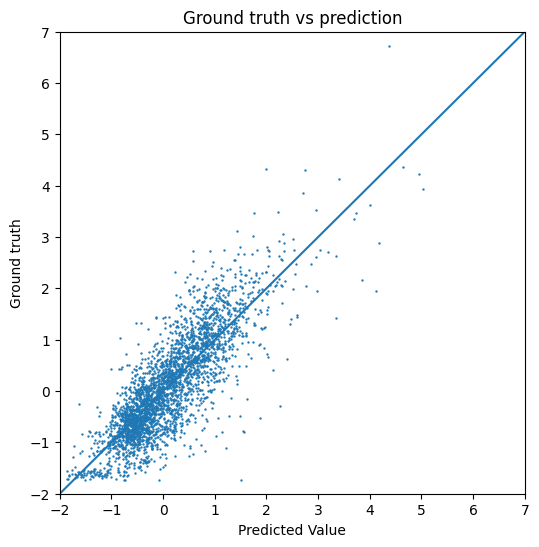

In [19]:
# 计算最佳 GIN 模型的测试损失（根据验证损失）

# 加载模型
model = GIN(dim_h=64)
model.load_state_dict(torch.load("GIN_best-model-parameters.pt"))

# 计算测试损失
gin_test_loss, gin_test_target, gin_test_y = testing(test_loader, model)

print("Test Loss for GIN: " + str(gin_test_loss.item()))

# 绘制预测值 vs 真实值
plot_targets(gin_test_target, gin_test_y)

## 讨论

在本教程中，我们首先介绍了两种不同的图神经网络。我们将这两种 GNN 应用于分子数据集以预测分子性质。我们展示了如何使用 *pytorch* 和 *pytorch_geometric* 训练和评估简单的 GNN。该模型可用于任何类型的图级回归任务，并且通过小的修改（如损失函数），图级分类也很容易实现。

GNN 的一个缺点是模型质量高度依赖于数据，训练集覆盖的化学空间越多，在新数据上的性能就越好。此外，训练模型可能相当复杂，因为有许多参数影响模型。模型参数，如学习率、批大小和隐藏维度数量，可以进行更彻底的评估以改进模型。要将其应用于实际任务，首先需要更大的数据集。当使用整个 QM9 数据集而不仅仅是小子集时，性能将会提高。此外，模型参数也仍然可以优化。模型架构也可以调整。这些更改可能导致更长的运行时间，这就是我们选择这个简化版本用于演示的原因。


## 测验

1. GCN 和 GIN 有什么区别？
2. 你将如何改变模型以适应分类任务？
3. 还有哪些参数可以调整以获得更好的模型性能？
